<a href="https://colab.research.google.com/github/raphaellebobillierarchbold-sudo/Week4_Unsupervised_Echo_Classification/blob/main/Chapter1_Unsupervised_Learning_Methods_Michel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning

This section marks our journey into another significant domain of machine learning and AI: unsupervised learning. Rather than delving deep into theoretical intricacies, our focus here will be on offering a practical guide. We aim to equip you with a clear understanding and effective tools for employing unsupervised learning methods in real-world (EO) scenarios.

It's important to note that, while unsupervised learning encompasses a broad range of applications, our discussion will predominantly revolve around classification tasks. This is because unsupervised learning techniques are exceptionally adept at identifying patterns and categorising data when the classifications are not explicitly labeled. By exploring these techniques, you'll gain insights into how to discern structure and relationships within your datasets, even in the absence of predefined categories or labels.

The tasks in this notebook will be mainly two:
1. Discrimination of Sea ice and lead based on image classification based on Sentinel-2 optical data.
2. Discrimination of Sea ice and lead based on altimetry data classification based on Sentinel-3 altimetry data.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Introduction to Unsupervised Learning Methods {cite}`bishop2006pattern`

### Introduction to K-means Clustering

K-means clustering is a type of unsupervised learning algorithm used for partitioning a dataset into a set of k groups (or clusters), where k represents the number of groups pre-specified by the analyst. It classifies the data points based on the similarity of the features of the data {cite}`macqueen1967some`. The basic idea is to define k centroids, one for each cluster, and then assign each data point to the nearest centroid, while keeping the centroids as small as possible.

### Why K-means for Clustering?

K-means clustering is particularly well-suited for applications where:

- **The structure of the data is not known beforehand**: K-means doesn’t require any prior knowledge about the data distribution or structure, making it ideal for exploratory data analysis.
- **Simplicity and scalability**: The algorithm is straightforward to implement and can scale to large datasets relatively easily.

### Key Components of K-means

1. **Choosing K**: The number of clusters (k) is a parameter that needs to be specified before applying the algorithm.
2. **Centroids Initialization**: The initial placement of the centroids can affect the final results.
3. **Assignment Step**: Each data point is assigned to its nearest centroid, based on the squared Euclidean distance.
4. **Update Step**: The centroids are recomputed as the center of all the data points assigned to the respective cluster.

### The Iterative Process of K-means

The assignment and update steps are repeated iteratively until the centroids no longer move significantly, meaning the within-cluster variation is minimised. This iterative process ensures that the algorithm converges to a result, which might be a local optimum.

### Advantages of K-means

- **Efficiency**: K-means is computationally efficient.
- **Ease of interpretation**: The results of k-means clustering are easy to understand and interpret.

### Basic Code Implementation

Below, you'll find a basic implementation of the K-means clustering algorithm. This serves as a foundational understanding and a starting point for applying the algorithm to your specific data analysis tasks.


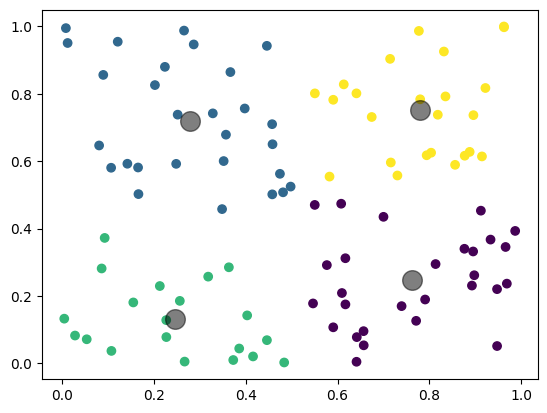

In [12]:
# Python code for K-means clustering
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Sample data
X = np.random.rand(100, 2)

# K-means model
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Plotting
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.show()


## Gaussian Mixture Models (GMM) {cite}`bishop2006pattern`

### Introduction to Gaussian Mixture Models

Gaussian Mixture Models (GMM) are a probabilistic model for representing normally distributed subpopulations within an overall population. The model assumes that the data is generated from a mixture of several Gaussian distributions, each with its own mean and variance {cite}`reynolds2009gaussian, mclachlan2004finite`. GMMs are widely used for clustering and density estimation, as they provide a method for representing complex distributions through the combination of simpler ones.

### Why Gaussian Mixture Models for Clustering?

Gaussian Mixture Models are particularly powerful in scenarios where:

- **Soft clustering is needed**: Unlike K-means, GMM provides the probability of each data point belonging to each cluster, offering a soft classification and understanding of the uncertainties in our data.
- **Flexibility in cluster covariance**: GMM allows for clusters to have different sizes and different shapes, making it more flexible to capture the true variance in the data.

### Key Components of GMM

1. **Number of Components (Gaussians)**: Similar to K in K-means, the number of Gaussians (components) is a parameter that needs to be set.
2. **Expectation-Maximization (EM) Algorithm**: GMMs use the EM algorithm for fitting, iteratively improving the likelihood of the data given the model.
3. **Covariance Type**: The shape, size, and orientation of the clusters are determined by the covariance type of the Gaussians (e.g., spherical, diagonal, tied, or full covariance).

### The EM Algorithm in GMM

The Expectation-Maximization (EM) algorithm is a two-step process:

- **Expectation Step (E-step)**: Calculate the probability that each data point belongs to each cluster.
- **Maximization Step (M-step)**: Update the parameters of the Gaussians (mean, covariance, and mixing coefficient) to maximize the likelihood of the data given these assignments.

This process is repeated until convergence, meaning the parameters do not significantly change from one iteration to the next.

### Advantages of GMM

- **Soft Clustering**: Provides a probabilistic framework for soft clustering, giving more information about the uncertainties in the data assignments.
- **Cluster Shape Flexibility**: Can adapt to ellipsoidal cluster shapes, thanks to the flexible covariance structure.

### Basic Code Implementation

Below, you'll find a basic implementation of the Gaussian Mixture Model. This should serve as an initial guide for understanding the model and applying it to your data analysis projects.


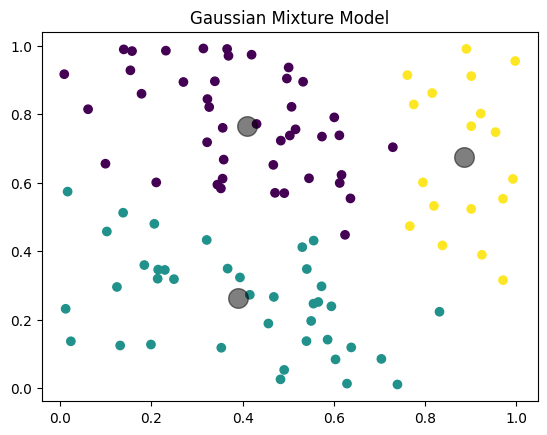

In [13]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

# Sample data
X = np.random.rand(100, 2)

# GMM model
gmm = GaussianMixture(n_components=3)
gmm.fit(X)
y_gmm = gmm.predict(X)

# Plotting
plt.scatter(X[:, 0], X[:, 1], c=y_gmm, cmap='viridis')
centers = gmm.means_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title('Gaussian Mixture Model')
plt.show()


In [14]:
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os

base_path = "/content/drive/MyDrive/week4/S2A_MSIL1C_20190301T235611_N0207_R116_T01WCU_20190302T014622.SAFE/GRANULE/L1C_T01WCU_A019275_20190301T235610/IMG_DATA/"

bands_paths = {
    "B4": os.path.join(base_path, "T01WCU_20190301T235611_B04.jp2"),
    "B3": os.path.join(base_path, "T01WCU_20190301T235611_B03.jp2"),
    "B2": os.path.join(base_path, "T01WCU_20190301T235611_B02.jp2"),
}

# sanity check
for b, p in bands_paths.items():
    print(b, os.path.exists(p), p)

B4 True /content/drive/MyDrive/week4/S2A_MSIL1C_20190301T235611_N0207_R116_T01WCU_20190302T014622.SAFE/GRANULE/L1C_T01WCU_A019275_20190301T235610/IMG_DATA/T01WCU_20190301T235611_B04.jp2
B3 True /content/drive/MyDrive/week4/S2A_MSIL1C_20190301T235611_N0207_R116_T01WCU_20190302T014622.SAFE/GRANULE/L1C_T01WCU_A019275_20190301T235610/IMG_DATA/T01WCU_20190301T235611_B03.jp2
B2 True /content/drive/MyDrive/week4/S2A_MSIL1C_20190301T235611_N0207_R116_T01WCU_20190302T014622.SAFE/GRANULE/L1C_T01WCU_A019275_20190301T235610/IMG_DATA/T01WCU_20190301T235611_B02.jp2


In [8]:
import rasterio

In [9]:
print(type(bands_paths), bands_paths.keys())

NameError: name 'bands_paths' is not defined

In [10]:
import os
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/week4/S2A_MSIL1C_20190301T235611_N0207_R116_T01WCU_20190302T014622.SAFE/GRANULE/L1C_T01WCU_A019275_20190301T235610/IMG_DATA/"

bands_paths = {
    "B4": os.path.join(base_path, "T01WCU_20190301T235611_B04.jp2"),
    "B3": os.path.join(base_path, "T01WCU_20190301T235611_B03.jp2"),
    "B2": os.path.join(base_path, "T01WCU_20190301T235611_B02.jp2"),
}

print("bands_paths keys:", bands_paths.keys())
for b,p in bands_paths.items():
    print(b, os.path.exists(p))

bands_paths keys: dict_keys(['B4', 'B3', 'B2'])
B4 True
B3 True
B2 True


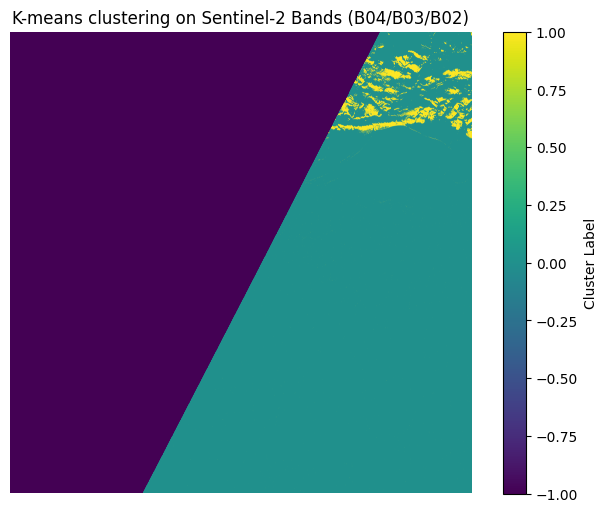

In [11]:
# Read and stack the band images
band_data = []
for band in ["B4", "B3", "B2"]:
    with rasterio.open(bands_paths[band]) as src:
        band_data.append(src.read(1))

band_stack = np.dstack(band_data)
valid_data_mask = np.all(band_stack > 0, axis=2)

X = band_stack[valid_data_mask].reshape((-1, 3))

kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
labels = kmeans.labels_

labels_image = np.full(band_stack.shape[:2], -1, dtype=int)
labels_image[valid_data_mask] = labels

plt.figure(figsize=(8,6))
plt.imshow(labels_image, cmap="viridis")
plt.title("K-means clustering on Sentinel-2 Bands (B04/B03/B02)")
plt.colorbar(label="Cluster Label")
plt.axis("off")
plt.show()

## Image Classification
Now, let's explore the application of these unsupervised methods to image classification tasks, focusing specifically on distinguishing between sea ice and leads in Sentinel-2 imagery.

### K-Means Implementation

In [4]:
! ls "/content/drive/MyDrive/week4/"


'Copy of Unit_2_Unsupervised_Learning_Methods_updated.ipynb'
 derived
 S2A_MSIL1C_20190301T235611_N0207_R116_T01WCU_20190302T014622.SAFE
 S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3
 Unit_1_Data_Colocating_S2_S3.ipynb
 Unit_2_Unsupervised_Learning_Methods.ipynb
 Unit_2_Unsupervised_Learning_Methods_updated.ipynb
 Week4_Echo_Classification.ipynb
'Week 4 echo classification notebook.ipynb'


In [3]:
! pip install rasterio

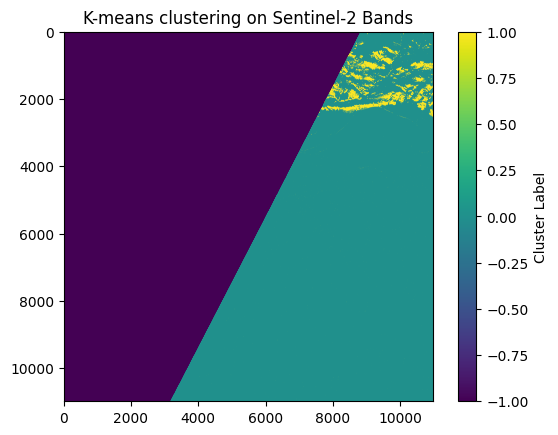

In [1]:
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/week4/S2A_MSIL1C_20190301T235611_N0207_R116_T01WCU_20190302T014622.SAFE/GRANULE/L1C_T01WCU_A019275_20190301T235610/IMG_DATA/"
bands_paths = {
    'B4': base_path + 'T01WCU_20190301T235611_B04.jp2',
    'B3': base_path + 'T01WCU_20190301T235611_B03.jp2',
    'B2': base_path + 'T01WCU_20190301T235611_B02.jp2'
}

# Read and stack the band images
band_data = []
for band in ['B4', 'B3', 'B2']:
    with rasterio.open(bands_paths[band]) as src:
        band_data.append(src.read(1))

# Stack bands and create a mask for valid data (non-zero values in all bands)
band_stack = np.dstack(band_data)
valid_data_mask = np.all(band_stack > 0, axis=2)

# Reshape for K-means, only including valid data
X = band_stack[valid_data_mask].reshape((-1, 3))

# K-means clustering
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
labels = kmeans.labels_

# Create an empty array for the result, filled with a no-data value (e.g., -1)
labels_image = np.full(band_stack.shape[:2], -1, dtype=int)

# Place cluster labels in the locations corresponding to valid data
labels_image[valid_data_mask] = labels

# Plotting the result
plt.imshow(labels_image, cmap='viridis')
plt.title('K-means clustering on Sentinel-2 Bands')
plt.colorbar(label='Cluster Label')
plt.show()


### GMM Implementation

In [ ]:
import rasterio
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Paths to the band images
base_path = base_path = "/content/drive/MyDrive/week4/S2A_MSIL1C_20190301T235611_N0207_R116_T01WCU_20190302T014622.SAFE/GRANULE/L1C_T01WCU_A019275_20190301T235610/IMG_DATA/"
bands_paths = {
    'B4': base_path + 'T01WCU_20190301T235611_B04.jp2',
    'B3': base_path + 'T01WCU_20190301T235611_B03.jp2',
    'B2': base_path + 'T01WCU_20190301T235611_B02.jp2'
}

# Read and stack the band images
band_data = []
for band in ['B4', 'B3', 'B2']:
    with rasterio.open(bands_paths[band]) as src:
        band_data.append(src.read(1))

# Stack bands and create a mask for valid data (non-zero values in all bands)
band_stack = np.dstack(band_data)
valid_data_mask = np.all(band_stack > 0, axis=2)

# Reshape for GMM, only including valid data
X = band_stack[valid_data_mask].reshape((-1, 3))

# GMM clustering
gmm = GaussianMixture(n_components=2, random_state=0).fit(X)
labels = gmm.predict(X)

# Create an empty array for the result, filled with a no-data value (e.g., -1)
labels_image = np.full(band_stack.shape[:2], -1, dtype=int)

# Place GMM labels in the locations corresponding to valid data
labels_image[valid_data_mask] = labels

# Plotting the result
plt.imshow(labels_image, cmap='viridis')
plt.title('GMM clustering on Sentinel-2 Bands')
plt.colorbar(label='Cluster Label')
plt.show()


In [ ]:
plt.pcolor(labels_image[8000:10000,8000:10000])

## Altimetry Classification
Now, let's explore the application of these unsupervised methods to altimetry classification tasks, focusing specifically on distinguishing between sea ice and leads in Sentinel-3 altimetry dataset.

### Read in Functions Needed
Before delving into the modeling process, it's crucial to preprocess the data to ensure compatibility with our analytical models. This involves transforming the raw data into meaningful variables, such as peakniness and stack standard deviation (SSD), etc.

In [11]:
! pip install netCDF4

In [13]:
path = "/content/drive/MyDrive/week4/"
SAR_file = "S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3"

In [14]:
print("SAR_data exists?", "SAR_data" in globals())

SAR_data exists? False


In [15]:
import os, glob

path = "/content/drive/MyDrive/week4/"
SAR_file = "S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3"

sen3_dir = os.path.join(path, SAR_file)
print("SEN3 exists?", os.path.exists(sen3_dir))
print("Top-level contents (first 30):")
print(*os.listdir(sen3_dir)[:30], sep="\n")

nc_files = glob.glob(os.path.join(sen3_dir, "*.nc"))
print("\nNetCDF files:")
print(*nc_files, sep="\n")

SEN3 exists? True
Top-level contents (first 30):
enhanced_measurement.nc
xfdumanifest.xml
standard_measurement.nc

NetCDF files:
/content/drive/MyDrive/week4/S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3/enhanced_measurement.nc
/content/drive/MyDrive/week4/S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3/standard_measurement.nc


In [16]:
!pip -q install netCDF4  # run once if netCDF4 not installed

from netCDF4 import Dataset
import os

path = "/content/drive/MyDrive/week4/"
SAR_file = "S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3"
sen3_dir = os.path.join(path, SAR_file)

sar_nc = os.path.join(sen3_dir, "enhanced_measurement.nc")  # or "standard_measurement.nc"
SAR_data = Dataset(sar_nc)

print("Opened:", sar_nc)
print("SAR_data exists?", "SAR_data" in globals())

Opened: /content/drive/MyDrive/week4/S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3/enhanced_measurement.nc
SAR_data exists? True


In [17]:
vars_list = list(SAR_data.variables.keys())
print("Number of variables:", len(vars_list))
print(*vars_list[:80], sep="\n")   # prints first 80 names

Number of variables: 306
time_01
time_20_ku
time_20_c
echo_sample_ind
wf_sample_ind
max_multi_stack_ind
UTC_day_01
UTC_sec_01
UTC_day_20_ku
UTC_sec_20_ku
UTC_day_20_c
UTC_sec_20_c
UTC_time_1hz_20_ku
UTC_time_1hz_20_c
lat_01
lon_01
lat_20_ku
lon_20_ku
lat_20_c
lon_20_c
surf_type_20_ku
surf_type_20_c
surf_class_01
surf_class_20_ku
surf_class_20_c
rad_surf_type_01
angle_coast_20_ku
dist_coast_20_ku
alt_20_ku
alt_20_c
orb_alt_rate_20_ku
orb_alt_rate_20_c
tracker_range_20_ku
tracker_range_20_c
tracker_range_20_plrm_ku
h0_nav_dem_20_ku
agc_20_ku
agc_20_c
agc_20_plrm_ku
agc_qual_20_ku
agc_qual_20_c
agc_qual_20_plrm_ku
scale_factor_20_ku
scale_factor_20_c
scale_factor_20_plrm_ku
range_water_20_ku
range_water_20_c
range_water_20_plrm_ku
range_water_qual_20_ku
range_water_qual_20_c
range_water_qual_20_plrm_ku
range_water_rms_01_ku
range_water_rms_01_c
range_water_rms_01_plrm_ku
range_water_numval_01_ku
range_water_numval_01_c
range_water_numval_01_plrm_ku
interpolated_c_band_range_water_20_ku
si

In [18]:
keywords = ["wave", "echo", "pwr", "power", "sigma", "sig", "pp", "peak", "ssd", "stack", "class", "flag", "surf"]
for k in keywords:
    hits = [v for v in vars_list if k.lower() in v.lower()]
    if hits:
        print("\n", k, "->", hits[:30])


 wave -> ['waveform_20_ku', 'waveform_20_c', 'waveform_20_plrm_ku', 'waveform_qual_ice_20_ku']

 echo -> ['echo_sample_ind']

 sigma -> ['sigmac_water_20_ku', 'sigmac_water_20_c', 'sigmac_water_20_plrm_ku']

 sig -> ['sig0_water_01_ku', 'sig0_water_01_c', 'sig0_water_01_plrm_ku', 'sig0_water_20_ku', 'sig0_water_20_c', 'sig0_water_20_plrm_ku', 'sig0_water_qual_01_ku', 'sig0_water_qual_01_c', 'sig0_water_qual_01_plrm_ku', 'sig0_water_qual_20_ku', 'sig0_water_qual_20_c', 'sig0_water_qual_20_plrm_ku', 'sig0_water_rms_01_ku', 'sig0_water_rms_01_c', 'sig0_water_rms_01_plrm_ku', 'sig0_water_numval_01_ku', 'sig0_water_numval_01_c', 'sig0_water_numval_01_plrm_ku', 'sigmac_water_20_ku', 'sigmac_water_20_c', 'sigmac_water_20_plrm_ku', 'sig0_ocog_20_ku', 'sig0_ocog_20_c', 'sig0_sea_ice_sheet_20_ku', 'sig0_cal_20_ku', 'sig0_cal_20_c', 'sig0_cal_20_plrm_ku', 'mod_instr_cor_sig0_01_ku', 'mod_instr_cor_sig0_01_c', 'mod_instr_cor_sig0_01_plrm_ku']

 peak -> ['peakiness_1_20_ku', 'peakiness_1_20_c', 'p

In [19]:
#
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
# from mpl_toolkits.basemap import Basemap
import numpy.ma as ma
import glob
from matplotlib.patches import Polygon
import scipy.spatial as spatial
from scipy.spatial import KDTree

import pyproj
# import cartopy.crs as ccrs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, fcluster

#=========================================================================================================
#===================================  SUBFUNCTIONS  ======================================================
#=========================================================================================================

#*args and **kwargs allow you to pass an unspecified number of arguments to a function,
#so when writing the function definition, you do not need to know how many arguments will be passed to your function
#**kwargs allows you to pass keyworded variable length of arguments to a function.
#You should use **kwargs if you want to handle named arguments in a function.
#double star allows us to pass through keyword arguments (and any number of them).
def peakiness(waves, **kwargs):

    "finds peakiness of waveforms."

    #print("Beginning peakiness")
    # Kwargs are:
    #          wf_plots. specify a number n: wf_plots=n, to show the first n waveform plots. \

    import numpy as np
    import matplotlib
    import matplotlib.pyplot as plt
    import time

    print("Running peakiness function...")

    size=np.shape(waves)[0] #.shape property is a tuple of length .ndim containing the length of each dimensions
                            #Tuple of array dimensions.

    waves1=np.copy(waves)

    if waves1.ndim == 1: #number of array dimensions
        print('only one waveform in file')
        waves2=waves1.reshape(1,np.size(waves1)) #numpy.reshape(a, newshape, order='C'), a=array to be reshaped
        waves1=waves2

    # *args is used to send a non-keyworded variable length argument list to the function
    def by_row(waves, *args):
        "calculate peakiness for each waveform"
        maximum=np.nanmax(waves)
        if maximum > 0:

            maximum_bin=np.where(waves==maximum)
            #print(maximum_bin)
            maximum_bin=maximum_bin[0][0]
            waves_128=waves[maximum_bin-50:maximum_bin+78]

            waves=waves_128

            noise_floor=np.nanmean(waves[10:20])
            where_above_nf=np.where(waves > noise_floor)

            if np.shape(where_above_nf)[1] > 0:
                maximum=np.nanmax(waves[where_above_nf])
                total=np.sum(waves[where_above_nf])
                mean=np.nanmean(waves[where_above_nf])
                peaky=maximum/mean

            else:
                peaky = np.nan
                maximum = np.nan
                total = np.nan

        else:
            peaky = np.nan
            maximum = np.nan
            total = np.nan

        if 'maxs' in args:
            return maximum
        if 'totals' in args:
            return total
        if 'peaky' in args:
            return peaky

    peaky=np.apply_along_axis(by_row, 1, waves1, 'peaky') #numpy.apply_along_axis(func1d, axis, arr, *args, **kwargs)

    if 'wf_plots' in kwargs:
        maximums=np.apply_along_axis(by_row, 1, waves1, 'maxs')
        totals=np.apply_along_axis(by_row, 1, waves1, 'totals')

        for i in range(0,kwargs['wf_plots']):
            if i == 0:
                print("Plotting first "+str(kwargs['wf_plots'])+" waveforms")

            plt.plot(waves1[i,:])#, a, col[i],label=label[i])
            plt.axhline(maximums[i], color='green')
            plt.axvline(10, color='r')
            plt.axvline(19, color='r')
            plt.xlabel('Bin (of 256)')
            plt.ylabel('Power')
            plt.text(5,maximums[i],"maximum="+str(maximums[i]))
            plt.text(5,maximums[i]-2500,"total="+str(totals[i]))
            plt.text(5,maximums[i]-5000,"peakiness="+str(peaky[i]))
            plt.title('waveform '+str(i)+' of '+str(size)+'\n. Noise floor average taken between red lines.')
            plt.show()


    return peaky

#=========================================================================================================
#=========================================================================================================
#=========================================================================================================


def unpack_gpod(variable):

    from scipy.interpolate import interp1d

    time_1hz=SAR_data.variables['time_01'][:]
    time_20hz=SAR_data.variables['time_20_ku'][:]
    time_20hzC = SAR_data.variables['time_20_c'][:]

    out=(SAR_data.variables[variable][:]).astype(float)  # convert from integer array to float.

    #if ma.is_masked(dataset.variables[variable][:]) == True:
    #print(variable,'is masked. Removing mask and replacing masked values with nan')
    out=np.ma.filled(out, np.nan)

    if len(out)==len(time_1hz):

        print(variable,'is 1hz. Expanding to 20hz...')
        out = interp1d(time_1hz,out,fill_value="extrapolate")(time_20hz)

    if len(out)==len(time_20hzC):
        print(variable, 'is c band, expanding to 20hz ku band dimension')
        out = interp1d(time_20hzC,out,fill_value="extrapolate")(time_20hz)
    return out


#=========================================================================================================
#=========================================================================================================
#=========================================================================================================

def calculate_SSD(RIP):

    from scipy.optimize import curve_fit
    from scipy import asarray as ar,exp
    do_plot='Off'

    def gaussian(x,a,x0,sigma):
            return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

    SSD=np.zeros(np.shape(RIP)[0])*np.nan
    x=np.arange(np.shape(RIP)[1])

    for i in range(np.shape(RIP)[0]):

        y=np.copy(RIP[i])
        y[(np.isnan(y)==True)]=0

        if 'popt' in locals():
            del(popt,pcov)

        SSD_calc=0.5*(np.sum(y**2)*np.sum(y**2)/np.sum(y**4))
        #print('SSD calculated from equation',SSD)

        #n = len(x)
        mean_est = sum(x * y) / sum(y)
        sigma_est = np.sqrt(sum(y * (x - mean_est)**2) / sum(y))
        #print('est. mean',mean,'est. sigma',sigma_est)

        try:
            popt,pcov = curve_fit(gaussian, x, y, p0=[max(y), mean_est, sigma_est],maxfev=10000)
        except RuntimeError as e:
            print("Gaussian SSD curve-fit error: "+str(e))
            #plt.plot(y)
            #plt.show()

        except TypeError as t:
            print("Gaussian SSD curve-fit error: "+str(t))

        if do_plot=='ON':

            plt.plot(x,y)
            plt.plot(x,gaussian(x,*popt),'ro:',label='fit')
            plt.axvline(popt[1])
            plt.axvspan(popt[1]-popt[2], popt[1]+popt[2], alpha=0.15, color='Navy')
            plt.show()

            print('popt',popt)
            print('curve fit SSD',popt[2])

        if 'popt' in locals():
            SSD[i]=abs(popt[2])


    return SSD


In [20]:
SAR_data.variables

{'time_01': <class 'netCDF4.Variable'>
 float64 time_01(time_01)
     long_name: UTC: 1 Hz
     units: seconds since 2000-01-01 00:00:00.0
     standard_name: time
     calendar: gregorian
 unlimited dimensions: 
 current shape = (1259,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'time_20_ku': <class 'netCDF4.Variable'>
 float64 time_20_ku(time_20_ku)
     long_name: UTC: 20 Hz Ku band
     units: seconds since 2000-01-01 00:00:00.0
     standard_name: time
     calendar: gregorian
     comment: Datation of SAR mode measurements (or LRM measurements acquired during early commissioning phase)
 unlimited dimensions: 
 current shape = (24827,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'time_20_c': <class 'netCDF4.Variable'>
 float64 time_20_c(time_20_c)
     long_name: UTC: 20 Hz C band
     units: seconds since 2000-01-01 00:00:00.0
     standard_name: time
     calendar: gregorian
     comment: Datation of C-band and Pseudo-LRM measurements
 un

In [27]:
from netCDF4 import Dataset
import os

path = "/content/drive/MyDrive/week4/"
SAR_file = "S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3"
print("overlapping SAR file is", SAR_file)

sar_nc = os.path.join(path, SAR_file, "enhanced_measurement.nc")
SAR_data = Dataset(sar_nc)
print("Opened:", sar_nc)

overlapping SAR file is S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3
Opened: /content/drive/MyDrive/week4/S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3/enhanced_measurement.nc


In [30]:
from netCDF4 import Dataset
import os
import numpy as np
from sklearn.preprocessing import StandardScaler

path = "/content/drive/MyDrive/week4/"
SAR_file = "S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3"
print("overlapping SAR file is", SAR_file)

sar_nc = os.path.join(path, SAR_file, "enhanced_measurement.nc")
SAR_data = Dataset(sar_nc)
print("Opened:", sar_nc)

# DO NOT keep the old line:
# SAR_data = Dataset(path + SAR_file + '/ .nc')

SAR_lat = unpack_gpod('lat_20_ku')
SAR_lon = unpack_gpod('lon_20_ku')
waves   = unpack_gpod('waveform_20_ku')
sig_0   = unpack_gpod('sig0_water_20_ku')
flag    = unpack_gpod('surf_type_20_ku')
SSD     = unpack_gpod('stdev_stack_20_ku')

PP = peakiness(waves)

data = np.column_stack((np.array(sig_0), np.array(PP), np.array(SSD)))
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data)

overlapping SAR file is S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3
Opened: /content/drive/MyDrive/week4/S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3/enhanced_measurement.nc
Running peakiness function...


/tmp/ipykernel_17320/541976555.py:67: RuntimeWarning: Mean of empty slice
  noise_floor=np.nanmean(waves[10:20])


In [35]:
path = path = "/content/drive/MyDrive/week4/"
SAR_file = "S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3"
print("overlapping SAR file is", SAR_file)
from netCDF4 import Dataset
import os

sar_nc = os.path.join(path, SAR_file, "enhanced_measurement.nc")  # or "standard_measurement.nc"
SAR_data = Dataset(sar_nc)
print("Opened:", sar_nc)


SAR_lat, SAR_lon, waves, sig_0, RIP, flag = unpack_gpod('lat_20_ku'), unpack_gpod('lon_20_ku'), unpack_gpod('waveform_20_ku'),unpack_gpod('sig0_water_20_ku'),unpack_gpod('rip_20_ku'),unpack_gpod('surf_type_class_20_ku') #unpack_gpod('Sigma0_20Hz')
SAR_index=np.arange(np.size(SAR_lat))

find=np.where(SAR_lat >= -99999)#60
SAR_lat=SAR_lat[find]
SAR_lon=SAR_lon[find]
SAR_index=SAR_index[find]
waves=waves[find]
sig_0=sig_0[find]
RIP=RIP[find]

PP=peakiness(waves)
SSD=calculate_SSD(RIP)
sig_0_np = np.array(sig_0)  # Replace [...] with your data
RIP_np = np.array(RIP)
PP_np = np.array(PP)
SSD_np = np.array(SSD)

data = np.column_stack((sig_0_np,PP_np, SSD_np))
# Standardize the data
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data)

overlapping SAR file is S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3
Opened: /content/drive/MyDrive/week4/S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3/enhanced_measurement.nc
Running peakiness function...


/tmp/ipykernel_17320/541976555.py:67: RuntimeWarning: Mean of empty slice
  noise_floor=np.nanmean(waves[10:20])


ImportError: cannot import name 'asarray' from 'scipy' (/usr/local/lib/python3.12/dist-packages/scipy/__init__.py)

In [31]:
flag.shape

(24827,)

In [32]:
waves.shape

(24827, 256)

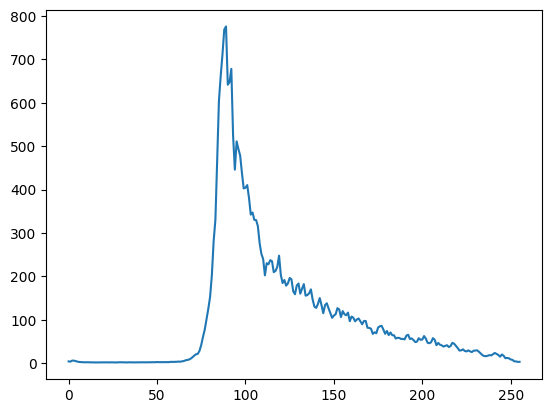

In [33]:
plt.plot(waves[1000])

In [79]:
import numpy as np

# 1) Remove any rows with NaNs in normalized features (or raw features)
valid_feat = ~np.isnan(data_normalized).any(axis=1)

# Apply to everything so lengths match
waves_cleaned = waves[valid_feat]
sig_0_cleaned = np.array(sig_0)[valid_feat]
PP_cleaned    = np.array(PP)[valid_feat]
SSD_cleaned   = np.array(SSD)[valid_feat]
flag_cleaned  = np.array(flag)[valid_feat]
data_norm_cleaned = data_normalized[valid_feat]

print("After NaN filter:", waves_cleaned.shape, data_norm_cleaned.shape, flag_cleaned.shape)

After NaN filter: (23894, 256) (23894, 3) (23894,)


In [38]:
print("Unique flag values:", np.unique(flag_cleaned)[:50])

Unique flag values: [0. 1. 2. 3.]


In [80]:
waves_cleaned=waves[~np.isnan(data_normalized).any(axis=1)][(flag_cleaned==1)|(flag_cleaned==2)]

In [81]:
waves_cleaned.shape

(12195, 256)

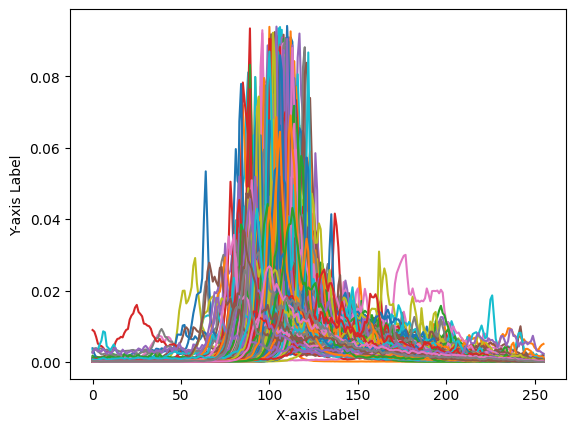

In [82]:
# Extract the first 5 functions where clusters_gmm is equal to 0
functions_to_plot = waves[~np.isnan(data_normalized).any(axis=1)][(flag_cleaned==1)][::10]

# Plot each function
for i, function in enumerate(functions_to_plot):
    plt.plot(function/np.sum(function))#, label=f'Function {i+1}')

plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
# plt.title('Plot of the first 5 functions where clusters_gmm is equal to 0')
# plt.legend()
plt.show()

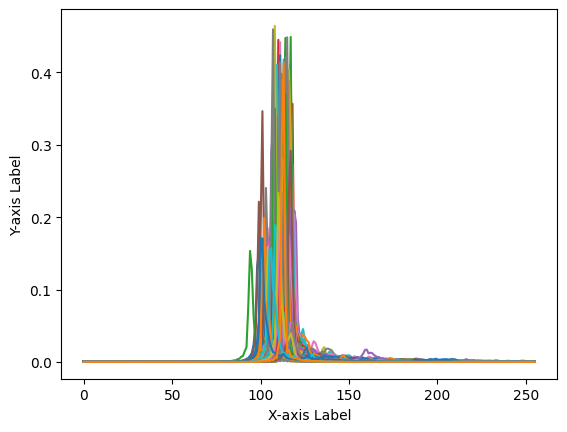

In [83]:
# Extract the first 5 functions where clusters_gmm is equal to 0
functions_to_plot = waves[~np.isnan(data_normalized).any(axis=1)][(flag_cleaned==2)][::10]

# Plot each function
for i, function in enumerate(functions_to_plot):
    plt.plot(function/np.sum(function))#, label=f'Function {i+1}')

plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
# plt.title('Plot of the first 5 functions where clusters_gmm is equal to 0')
# plt.legend()
plt.show()

In [84]:
data_normalized.shape

(24827, 3)

There are some NaN values in the dataset so one way to deal with this is

1.   List item
2.   List item

to delete them.

In [85]:
nan_count = np.isnan(data_normalized).sum()
print(f"Number of NaN values in the array: {nan_count}")
data_cleaned = data_normalized[~np.isnan(data_normalized).any(axis=1)]
flag_cleaned = flag[~np.isnan(data_normalized).any(axis=1)]


Number of NaN values in the array: 1280


Now, let's proceed with running the GMM model as usual. Remember, you have the flexibility to substitute this with K-Means or any other preferred model.

In [86]:
data_cleaned.shape

(23894, 3)

In [87]:
flag_cleaned.shape

(23894,)

In [88]:
data_cleaned[(flag_cleaned==1)|(flag_cleaned==2)].shape

(12195, 3)

In [89]:
gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(data_cleaned[(flag_cleaned==1)|(flag_cleaned==2)])
clusters_gmm = gmm.predict(data_cleaned[(flag_cleaned==1)|(flag_cleaned==2)])

We can also inspect how many data points are there in each class of your clustering prediction.

In [90]:
unique, counts = np.unique(clusters_gmm, return_counts=True)
class_counts = dict(zip(unique, counts))

print(class_counts)

{np.int64(0): np.int64(8694), np.int64(1): np.int64(3501)}


In [91]:
clusters_gmm.shape


(12195,)

In [92]:
waves.shape

(24827, 256)

In [93]:
data_normalized.shape

(24827, 3)

In [94]:
waves_cleaned=waves[~np.isnan(data_normalized).any(axis=1)][(flag_cleaned==1)|(flag_cleaned==2)]

In [95]:
waves_cleaned.shape

(12195, 256)

In [96]:
# plt.plot(np.std(waves_cleaned[clusters_gmm==0],axis=0),label='ice')


In [97]:
waves_cleaned[clusters_gmm==0].shape

(8694, 256)

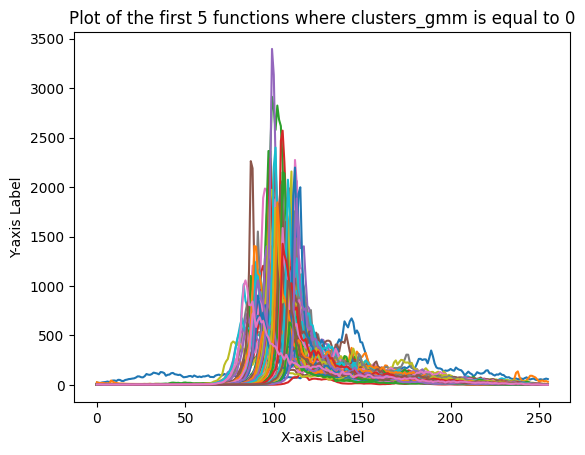

In [98]:
# Extract the first 5 functions where clusters_gmm is equal to 0
functions_to_plot = waves_cleaned[clusters_gmm == 0][::100]

# Plot each function
for i, function in enumerate(functions_to_plot):
    plt.plot(function)#, label=f'Function {i+1}')

plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Plot of the first 5 functions where clusters_gmm is equal to 0')
# plt.legend()
plt.show()

In [99]:
waves_cleaned.shape

(12195, 256)

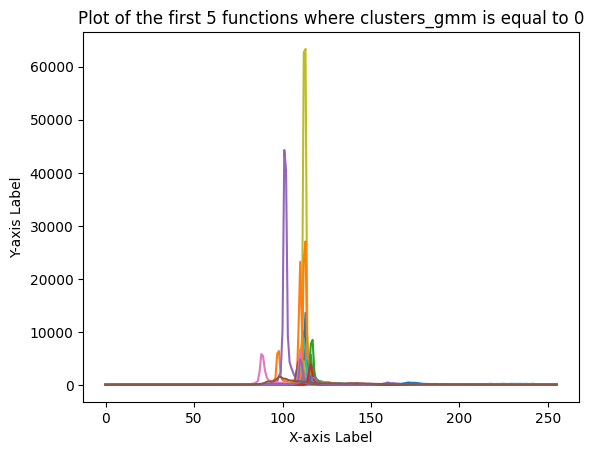

In [100]:
# Extract the first 5 functions where clusters_gmm is equal to 0
functions_to_plot = waves_cleaned[clusters_gmm == 1][::100]

# Plot each function
for i, function in enumerate(functions_to_plot):
    plt.plot(function)#, label=f'Function {i+1}')

plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Plot of the first 5 functions where clusters_gmm is equal to 0')
# plt.legend()
plt.show()

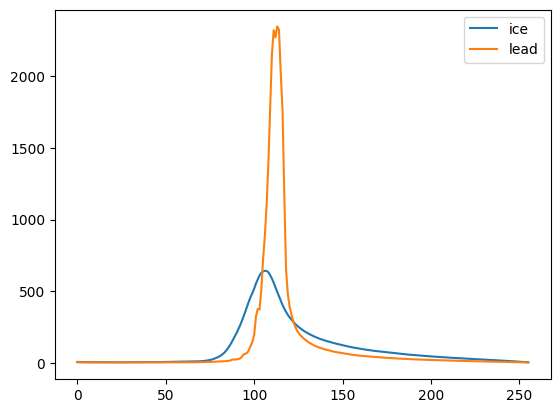

In [101]:
plt.plot(np.mean(waves_cleaned[clusters_gmm==0],axis=0),label='ice')
plt.plot(np.mean(waves_cleaned[clusters_gmm==1],axis=0),label='lead')
plt.legend()

In [63]:
#5 Classes

In [102]:
gmm = GaussianMixture(n_components=5, random_state=0)
gmm.fit(data_cleaned[(flag_cleaned==1)|(flag_cleaned==2)])
clusters_gmm = gmm.predict(data_cleaned[(flag_cleaned==1)|(flag_cleaned==2)])

In [103]:
unique, counts = np.unique(clusters_gmm, return_counts=True)
class_counts = dict(zip(unique, counts))

print(class_counts)

{np.int64(0): np.int64(3622), np.int64(1): np.int64(1487), np.int64(2): np.int64(1857), np.int64(3): np.int64(2937), np.int64(4): np.int64(2292)}


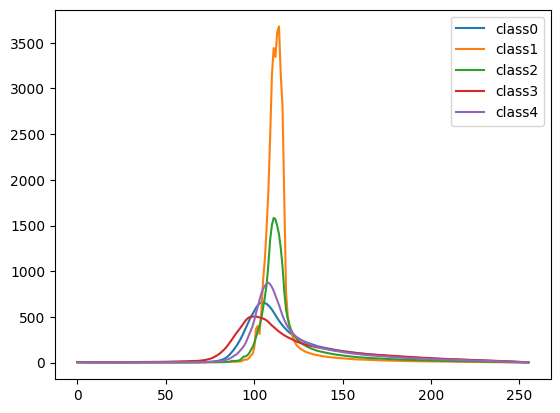

In [104]:
plt.plot(np.mean(waves_cleaned[clusters_gmm==0],axis=0),label='class0')
plt.plot(np.mean(waves_cleaned[clusters_gmm==1],axis=0),label='class1')
plt.plot(np.mean(waves_cleaned[clusters_gmm==2],axis=0),label='class2')
plt.plot(np.mean(waves_cleaned[clusters_gmm==3],axis=0),label='class3')
plt.plot(np.mean(waves_cleaned[clusters_gmm==4],axis=0),label='class4')
plt.legend()

In [105]:
gmm = GaussianMixture(n_components=10, random_state=0)
gmm.fit(data_cleaned)
clusters_gmm = gmm.predict(data_cleaned)

In [106]:
unique, counts = np.unique(clusters_gmm, return_counts=True)
class_counts = dict(zip(unique, counts))

print(class_counts)

{np.int64(0): np.int64(3852), np.int64(1): np.int64(2169), np.int64(2): np.int64(5605), np.int64(3): np.int64(1024), np.int64(4): np.int64(369), np.int64(5): np.int64(767), np.int64(6): np.int64(1268), np.int64(7): np.int64(1511), np.int64(8): np.int64(2282), np.int64(9): np.int64(5047)}


In [107]:
print("waves_cleaned:", waves_cleaned.shape)
print("data_norm_cleaned:", data_norm_cleaned.shape)

waves_cleaned: (12195, 256)
data_norm_cleaned: (23894, 3)


In [109]:
import numpy as np

# 1) mask for valid features
valid_feat = ~np.isnan(data_normalized).any(axis=1)

# 2) mask for desired ESA classes (1 and 2)
flag_all = np.array(flag)
keep_class = (flag_all == 1) | (flag_all == 2)

# 3) combined mask
keep = valid_feat & keep_class

# 4) apply to BOTH (and any other arrays used later)
waves_cleaned = waves[keep]
data_norm_cleaned = data_normalized[keep]
flag_cleaned = flag_all[keep]

print("waves_cleaned:", waves_cleaned.shape)
print("data_norm_cleaned:", data_norm_cleaned.shape)
print("flag unique:", np.unique(flag_cleaned))

waves_cleaned: (12195, 256)
data_norm_cleaned: (12195, 3)
flag unique: [1. 2.]


In [111]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0).fit(data_norm_cleaned)
clusters = kmeans.labels_
print("clusters shape:", clusters.shape, "unique:", np.unique(clusters))

clusters shape: (12195,) unique: [0 1]


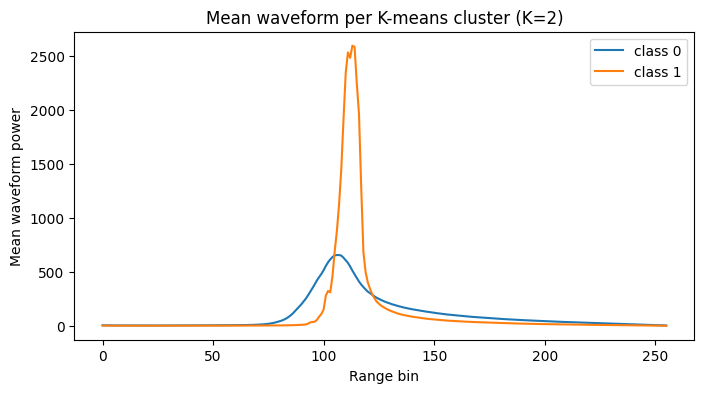

In [113]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,4))

for c in np.unique(clusters):
    plt.plot(np.mean(waves_cleaned[clusters == c], axis=0), label=f"class {c}")

plt.legend()
plt.xlabel("Range bin")
plt.ylabel("Mean waveform power")
plt.title("Mean waveform per K-means cluster (K=2)")
plt.show()

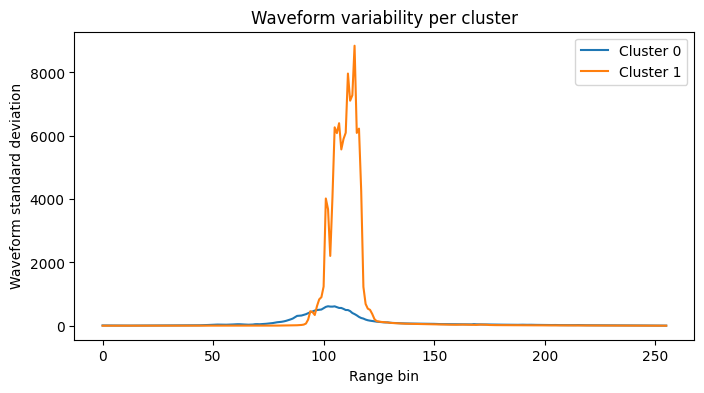

In [115]:
plt.figure(figsize=(8,4))

for c in np.unique(clusters):
    std_wave = np.std(waves_cleaned[clusters == c], axis=0)
    plt.plot(std_wave, label=f"Cluster {c}")

plt.legend()
plt.xlabel("Range bin")
plt.ylabel("Waveform standard deviation")
plt.title("Waveform variability per cluster")
plt.show()

In [116]:
print(clusters.shape, flag_cleaned.shape)

(12195,) (12195,)


In [120]:
# Convert ESA classes to 0/1
esa_binary = np.where(flag_cleaned == 1, 0, 1)

print("ESA unique:", np.unique(esa_binary))
print("Clusters unique:", np.unique(clusters))

ESA unique: [0 1]
Clusters unique: [0 1]


In [122]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(esa_binary, clusters)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(esa_binary, clusters))

Confusion Matrix:
 [[8877    1]
 [ 307 3010]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      8878
           1       1.00      0.91      0.95      3317

    accuracy                           0.97     12195
   macro avg       0.98      0.95      0.97     12195
weighted avg       0.98      0.97      0.97     12195



In [121]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(flag_cleaned, clusters)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(flag_cleaned, clusters))

Confusion Matrix:
 [[   0    0    0]
 [8877    1    0]
 [ 307 3010    0]]

Classification Report:

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       0.00      0.00      0.00      8878
         2.0       0.00      0.00      0.00      3317

    accuracy                           0.00     12195
   macro avg       0.00      0.00      0.00     12195
weighted avg       0.00      0.00      0.00     12195



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

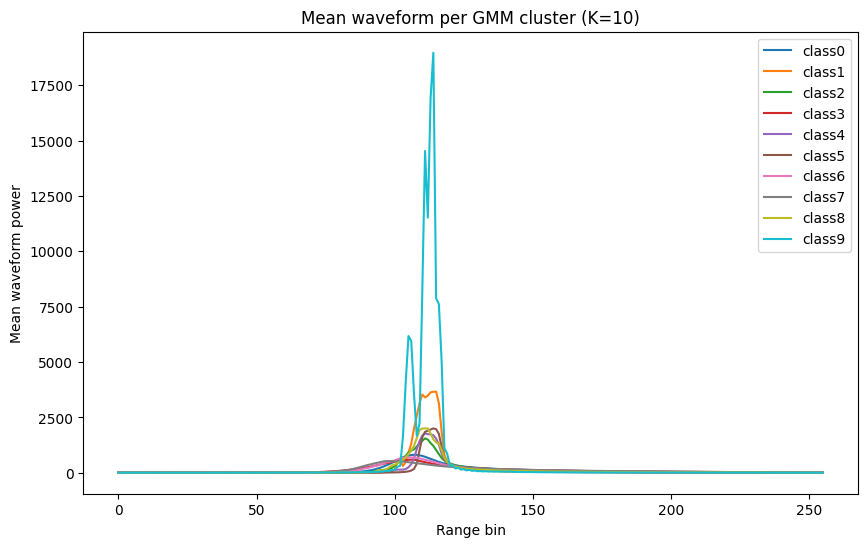

In [124]:
gmm = GaussianMixture(n_components=10, random_state=0)
gmm.fit(data_norm_cleaned)
clusters_gmm = gmm.predict(data_norm_cleaned)

plt.figure(figsize=(10, 6))
for i in range(10):
    if np.any(clusters_gmm == i):
        plt.plot(np.mean(waves_cleaned[clusters_gmm == i], axis=0), label=f'class{i}')
plt.legend()
plt.xlabel('Range bin')
plt.ylabel('Mean waveform power')
plt.title('Mean waveform per GMM cluster (K=10)')
plt.show()

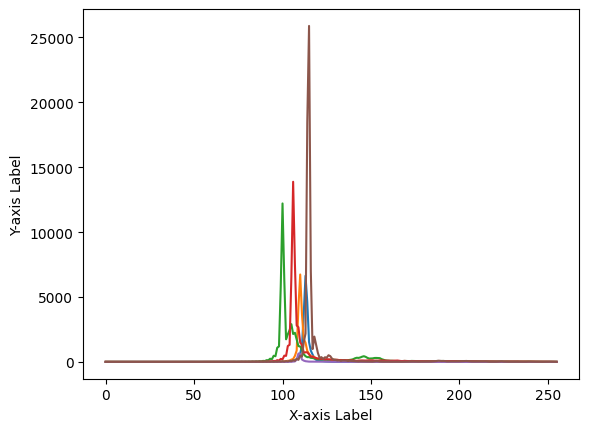

In [125]:
# Extract the first 5 functions where clusters_gmm is equal to 0
functions_to_plot = waves_cleaned[clusters_gmm == 8][::100]

# Plot each function
for i, function in enumerate(functions_to_plot):
    plt.plot(function)#, label=f'Function {i+1}')

plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
# plt.title('Plot of the first 5 functions where clusters_gmm is equal to 0')
# plt.legend()
plt.show()

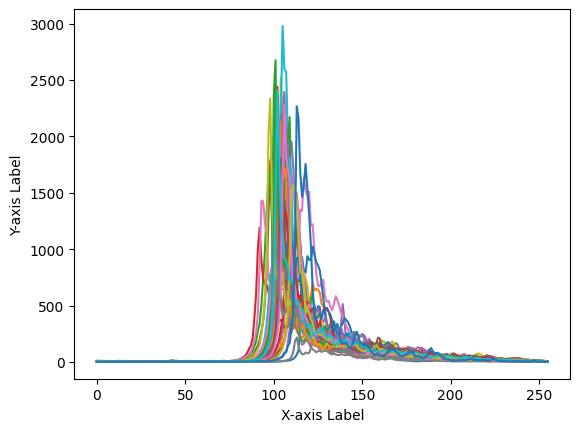

In [126]:
# Extract the first 5 functions where clusters_gmm is equal to 0
functions_to_plot = waves_cleaned[clusters_gmm == 0][::100]

# Plot each function
for i, function in enumerate(functions_to_plot):
    plt.plot(function)#, label=f'Function {i+1}')

plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
# plt.title('Plot of the first 5 functions where clusters_gmm is equal to 0')
# plt.legend()
plt.show()

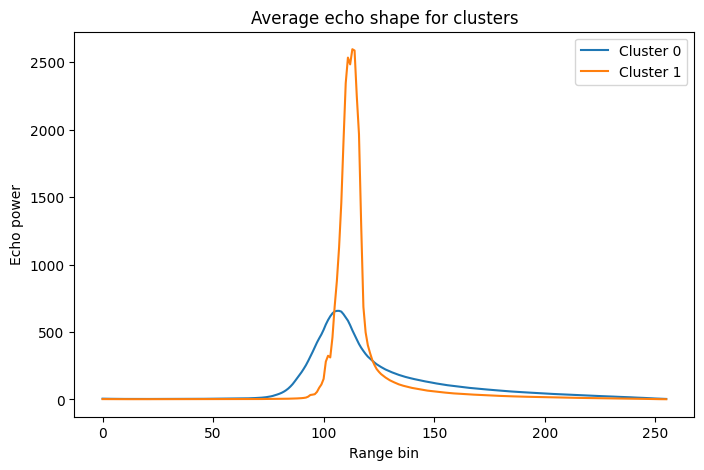

<Figure size 640x480 with 0 Axes>

In [130]:
plt.figure(figsize=(8,5))

plt.plot(np.mean(waves_cleaned[clusters==0], axis=0), label="Cluster 0")
plt.plot(np.mean(waves_cleaned[clusters==1], axis=0), label="Cluster 1")

plt.xlabel("Range bin")
plt.ylabel("Echo power")
plt.title("Average echo shape for clusters")
plt.legend()
plt.show()
plt.savefig("mean_echo_shape.png", dpi=300)

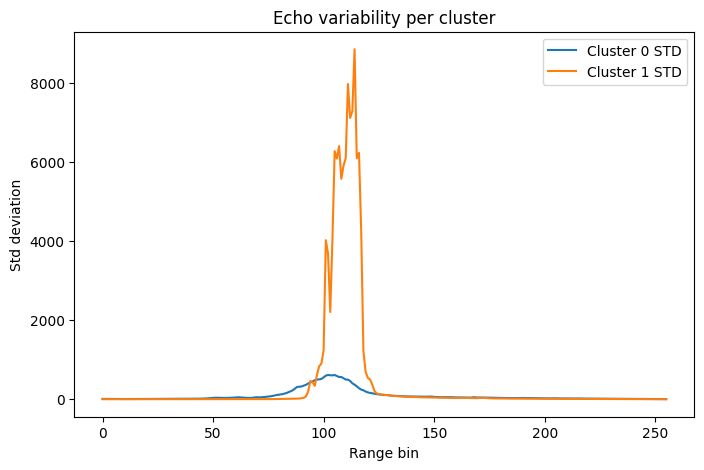

<Figure size 640x480 with 0 Axes>

In [131]:
plt.figure(figsize=(8,5))

plt.plot(np.std(waves_cleaned[clusters==0], axis=0), label="Cluster 0 STD")
plt.plot(np.std(waves_cleaned[clusters==1], axis=0), label="Cluster 1 STD")

plt.xlabel("Range bin")
plt.ylabel("Std deviation")
plt.title("Echo variability per cluster")
plt.legend()
plt.show()
plt.savefig("echo_std.png", dpi=300)

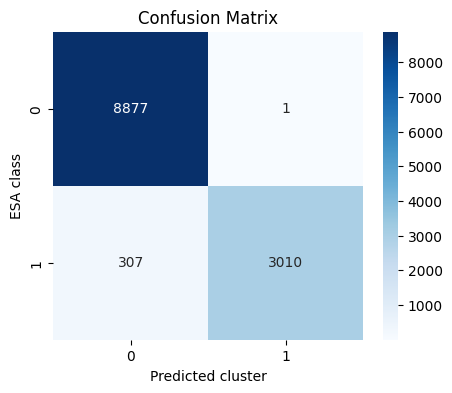

<Figure size 640x480 with 0 Axes>

In [132]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted cluster")
plt.ylabel("ESA class")
plt.title("Confusion Matrix")

plt.show()
plt.savefig("confusion_matrix.png", dpi=300)